# Indicator vs Monthly Return Testing

This notebook loads a JSON file containing indicator values and a monthly return variable, then automatically generates scatter plots of each indicator vs the monthly return.

In [57]:
import itertools
import json
import matplotlib.pyplot as plt
import numpy as np 
import os
import pandas as pd 
import warnings
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import cross_val_score
# For ARIMA model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# For ADF test (Augmented Dickey-Fuller)
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
# For ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [58]:
# Suppress warnings to keep your notebook output clean
warnings.filterwarnings("ignore")

# Ensure matplotlib plots render inline in the notebook
%matplotlib inline

In [59]:

print(os.getcwd())


c:\Users\micha\OneDrive\Desktop\TUE\HTT\HTTStockIndustryRankingTool\Notebooks


In [60]:
Path.cwd().parent

WindowsPath('c:/Users/micha/OneDrive/Desktop/TUE/HTT/HTTStockIndustryRankingTool')

In [61]:
path = Path.cwd().parent / "Data" / "oil_industry_data.json"
jdf = pd.read_json(path)
jdf

,XOM,CVX,SHEL,TTE,PBR,PBR.A,BP,EQNR,E,SU,...,CRT,PVL,PRT,USEG,MXC,CKX,EONR,BRN,MTR,TPET
2025-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
2025-09-30,NaN,"{'BOED': 6609000, 'OCF/BOED': 3502.79921319412...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 1000000, 'OCF/BOED': 0.336296, 'ROA':...",NaN,NaN,NaN,NaN
2025-06-30,NaN,"{'BOED': 3346500, 'OCF/BOED': 4113.25265202450...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 150000, 'OCF/BOED': 0.626840000000000...",NaN,NaN,NaN,NaN
2024-12-31,NaN,"{'BOED': 3338000, 'OCF/BOED': 9434.39185140802...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'BOED': 225.33, 'OCF/BOED': 13052.47858696134...","{'BOED': 22061.19, 'OCF/BOED': 9.2815029470305...",NaN,NaN,NaN,NaN
2025-03-31,NaN,"{'BOED': 13412000, 'OCF/BOED': 386.89233522218...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 100000, 'OCF/BOED': 1.186640000000000...",NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1996-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1996-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1995-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN


In [62]:
s = jdf.stack()
s = s[s.map(type).eq(dict)]

out = pd.json_normalize(s.values)
out.index = s.index
out = out.reset_index()
out.columns = ['Date', 'Ticker'] + list(out.columns[2:])
out = out.drop(columns='Date')
out

,Ticker,BOED,OCF/BOED,ROA,CostExpenses/BOED,Stock/Oil ZScore,PGR,Monthly Return
0,NFG,53051.0,5182.202032,1.973143,7075.908088,2.825966,11.730000,8.880840
1,COP,224000.0,88375.000000,6.550816,29205.357143,1.994985,21.739130,16.205524
2,FANG,497156.0,17616.200951,2.341716,27677.429217,2.364790,53.530000,12.146607
3,DVN,389000.0,17251.928021,8.361024,7275.064267,1.153904,-0.410000,20.229319
4,EXE,16164.0,283036.377134,6.430516,597191.289285,2.376671,90.672727,-6.895615
...,...,...,...,...,...,...,...,...
765,CKX,100000.0,4.419620,8.743000,2.191770,-0.371745,0.000000,-4.316563
766,CKX,21176000.0,0.020871,8.743000,0.010350,-0.371745,829.587357,-4.316563
767,MXC,104401.0,11.141186,0.976244,29.401519,-0.713093,0.000000,1.960771
768,CKX,17610000.0,0.025097,8.743000,0.012446,-0.371745,674.070000,-4.316563


In [63]:
# Make sure oil_industry_data.json is in the same level as this notebook
with open(path) as f:
    oil_industry_data =  json.load(f)

oil_industry_data

{'XOM': {'2025-12-31': None,
  '2025-09-30': None,
  '2025-06-30': None,
  '2024-12-31': None,
  '2025-03-31': None,
  '2024-09-30': None,
  '2024-06-30': None,
  '2023-12-31': None,
  '2024-03-31': None,
  '2023-09-30': None,
  '2023-06-30': None,
  '2022-12-31': None,
  '2023-03-31': None,
  '2022-09-30': None,
  '2022-06-30': None,
  '2021-12-31': None,
  '2022-03-31': None,
  '2020-12-31': None,
  '2020-09-30': None,
  '2020-06-30': None,
  '2019-12-31': None,
  '2020-03-31': None,
  '2019-09-30': None,
  '2019-06-30': None},
 'CVX': {'2025-09-30': {'BOED': 6609000,
   'OCF/BOED': 3502.799213194129,
   'ROA': 1.0839170477272657,
   'CostExpenses/BOED': 6704.796489635346,
   'Stock/Oil ZScore': 1.8907107808119483,
   'PGR': 7.22,
   'Monthly Return': -1.2685841273981846},
  '2025-06-30': {'BOED': 3346500,
   'OCF/BOED': 4113.252652024503,
   'ROA': 0.9927438003349015,
   'CostExpenses/BOED': 12154.489765426564,
   'Stock/Oil ZScore': 1.2948218978736037,
   'PGR': 1.66,
   'Monthly R

## ARIMA Models

Basic Arima (not used)

In [64]:
def ARIMA_Stock_Analysis(ticker):
    # ==========================================
    # 1. Load Data & Extract Ticker 
    # ==========================================
    # Using the exact absolute path you provided
    oil_stock_data = oil_industry_data.get(ticker, {})
    records = []

    # Parse dates and Monthly Return, skipping nulls
    for date_str, metrics in oil_stock_data.items():
        if metrics is not None and "Monthly Return" in metrics:
            records.append({
                "Date": pd.to_datetime(date_str),
                "Monthly Return": metrics["Monthly Return"]
            })

    if not records:
        raise ValueError(f"No valid data found for {ticker}.")

    # Create DataFrame, set Date as index, sort chronologically
    df = pd.DataFrame(records).set_index("Date").sort_index()

    # Resample to Quarterly frequency to ensure an even time-series
    df = df.resample('QE').mean().interpolate()
    ts_data = df["Monthly Return"]

    print(f"Successfully loaded {len(ts_data)} valid quarterly data points for {ticker}.")

    # ==========================================
    # 2. Stationarity Check (ADF Test)
    # ==========================================
    print("\n--- Step 1: Stationarity Check (ADF Test) ---")
    adf_result = adfuller(ts_data)
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")

    # Determine differencing parameter (d)
    d_val = 0 if adf_result[1] < 0.05 else 1
    print(f"-> Based on p-value, setting ARIMA differencing parameter (d) to: {d_val}")

    # ==========================================
    # 3. Autocorrelation Plots (ACF & PACF)
    # ==========================================
    print("\n--- Step 2: ACF & PACF Plots ---")
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(ts_data, ax=axes[0], title="Autocorrelation (ACF) -> Determines 'q'")
    plot_pacf(ts_data, ax=axes[1], title="Partial Autocorr (PACF) -> Determines 'p'")
    plt.tight_layout()
    plt.show() 

    # ==========================================
    # 4. Fit the ARIMA Model
    # ==========================================
    print("\n--- Step 3: Fitting ARIMA Model ---")
    p, q = 1, 1 
    model = ARIMA(ts_data, order=(p, d_val, q))
    fitted_model = model.fit()

    print(fitted_model.summary())

    # ==========================================
    # 5. Forecasting & Visualization (3 YEARS AHEAD)
    # ==========================================
    print("\n--- Step 4: Forecasting ---")
    # Forecast the next 12 periods (3 Years, since data is quarterly)
    forecast_steps = 12
    forecast = fitted_model.get_forecast(steps=forecast_steps)
    forecast_mean = forecast.predicted_mean
    conf_int = forecast.conf_int()

    plt.figure(figsize=(12, 6))
    plt.plot(ts_data.index, ts_data, label="Historical CVX Monthly Returns", color="#1f77b4", marker="o")
    plt.plot(ts_data.index, fitted_model.fittedvalues, label="Model Fitted Values", color="green", linestyle="-")
    plt.plot(forecast_mean.index, forecast_mean, label="Forecast (Next 3 Years / 12 Quarters)", color="#d62728", linestyle="--", marker="x")

    plt.fill_between(conf_int.index, 
                    conf_int.iloc[:, 0], 
                    conf_int.iloc[:, 1], 
                    color="#d62728", alpha=0.15, label="95% Confidence Interval")

    plt.title(f"{ticker} Monthly Return - ARIMA Model Forecast (3-Year Horizon)", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Monthly Return (%)", fontsize=12)
    plt.axhline(0, color="black", linewidth=1, linestyle="--")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()

Filtering Data to Determine which stock datasets are viable for training

In [65]:
def load_data_for_ticker(ticker):
    try:
        # Load Data & Extract Ticker data
        oil_stock_data = oil_industry_data.get(ticker, {})

        # Convert the nested dictionary directly into a Pandas DataFrame
        df = pd.DataFrame.from_dict(oil_stock_data, orient='index')
        df.index = pd.to_datetime(df.index)

        # Sort chronologically and resample to Quarterly
        df = df.sort_index().resample('QE').mean()

        # Drop any columns that are 100% empty, then interpolate missing values
        df = df.dropna(axis=1, how='all')
        df = df.interpolate(method='linear', limit_direction='both')
        return df
    except:
        return None

In [66]:
def enough_data_points(ticker_data):
    if ticker_data is None:
        return False
    else:
        if len(ticker_data) < 20:
            return False
        else:
            return True

In [67]:
def check_stationary_category(column_data):
    adf_result = adfuller(column_data)
    kpss_result = kpss(column_data)

    if (adf_result[1] < 0.05 and kpss_result[1] > 0.05):
        # Stationary
        return "stationary"
    elif (adf_result[1] > 0.05 and kpss_result[1] < 0.05):
        # Unit-Root
        return "unit-root"
    else:
        # Neither
        return "other"

In [68]:
def check_arima_category(ticker_data):
    columns = ["OCF/BOED", "ROA", "CostExpenses/BOED", "Stock/Oil ZScore", "PGR"]

    arima_category = {'stationary': 0, 'unit_root': 0, 'other': 0}
    for indicator in columns:
        arima_type = check_stationary_category(ticker_data[indicator])
        if arima_type == "stationary":
            arima_category['stationary'] += 1
        elif arima_type == "unit-root": 
            arima_category['unit_root'] += 1
        else:
            arima_category['other'] +=1

    return max(arima_category, key=arima_category.get)

In [69]:
unviable = []
unit_root = []
stationary = []
other = []

# Filter stock data for following criteria:
# Atleast 5 years worth of quarterly data, monthly return is stationary
for stock_ticker in oil_industry_data.keys():
    ticker_data = load_data_for_ticker(stock_ticker)
    if not enough_data_points(ticker_data):
        unviable.append(stock_ticker)
    else:
        if len(ticker_data.columns) == 0:
            unviable.append(stock_ticker)
            continue

        if check_stationary_category(ticker_data["Monthly Return"]) == "stationary":
            arima_category = check_arima_category(ticker_data)

            if arima_category == "stationary":
                stationary.append(stock_ticker)
            elif arima_category == "unit_root":
                unit_root.append(stock_ticker)
            else:
                other.append(stock_ticker)
        else:
            unviable.append(stock_ticker)

In [70]:
stationary

['CVX', 'NFG', 'DVN', 'EXE', 'MTDR', 'CNX', 'NOG']

In [71]:
unit_root

['RRC', 'TALO']

## ARIMA Model Training

In [72]:
p = range(0, 5)
q = range(0, 5)
trainingset_stationary = {}

In [73]:
def test_model(y_train, order):
    model = ARIMA(y_train, order=order)
    results = model.fit()
    return results

In [74]:
def create_trainingset(ticker_data, window_size=20, test_size=6, min_train_rows=6):
    y = ticker_data["Monthly Return"].dropna()

    indices = np.array_split(np.arange(len(y)), 2)
    y_blocks = [y.iloc[idx] for idx in indices]

    min_block_size = min(len(idx) for idx in indices)
    if test_size >= min_block_size:
        raise ValueError(f"Not enough data: min block size {min_block_size} <= test_size {test_size}")

    results = []

    for block_id in range(2):
        y_block_test = y_blocks[block_id].iloc[-test_size:]

        # Sliding window: fixed window_size rows immediately before the test window
        test_start_pos = int(indices[block_id][-test_size])
        train_start_pos = max(0, test_start_pos - window_size)
        y_block_train = y.iloc[train_start_pos:test_start_pos]

        if len(y_block_train) < min_train_rows:
            raise ValueError(f"Not enough training data in block {block_id}: {len(y_block_train)} rows < min_train_rows {min_train_rows}")

        results.append({'y_train': y_block_train, 'y_test': y_block_test})

    return {'blocks': results, 'y_aligned': y}

In [75]:
def calculate_expected_return(results, y_test):
    preds = results.get_forecast(steps=len(y_test)).predicted_mean
    returns = []

    for i, pred_value in enumerate(preds):
        if pred_value > 0:
            returns.append(y_test.iloc[i] / 100)
        else:
            returns.append(-y_test.iloc[i] / 100)

    returns_std = np.std(returns) if len(returns) > 0 else 0
    returns_mean = np.mean(returns) if len(returns) > 0 else 0

    sharpe_ratio = returns_mean / returns_std if returns_std > 0 else 0
    return sharpe_ratio

In [76]:
def train_ARIMA(ticker, d_val, window_size=20, test_size=6):
    training_split = create_trainingset(ticker, window_size=window_size, test_size=test_size)
    training_blocks = training_split['blocks']
    y_aligned = training_split['y_aligned']

    best_return = 0
    best_order = None
    weights = np.array([0.25, 0.75])

    for order in itertools.product(p, [d_val], q):
        try:
            ticker_models = [test_model(block['y_train'], order) for block in training_blocks]
            expected_returns = [calculate_expected_return(ticker_models[i], training_blocks[i]['y_test']) for i in range(len(training_blocks))]
            expected_return = sum(np.array(expected_returns) * weights)
            if expected_return > best_return:
                best_return = expected_return
                best_order = order
        except Exception as e:
            print(e)
            continue

    if best_order is None:
        raise ValueError("No valid ARIMA order found — all orders scored <= 0 or failed")

    print(f"Best ARIMA order: {best_order} with Expected Return: {best_return:.4f}")

    backtest_data = []
    for block in training_blocks:
        try:
            m = test_model(block['y_train'], best_order)
            preds = m.get_forecast(steps=len(block['y_test'])).predicted_mean
            preds.index = block['y_test'].index
        except Exception:
            preds = pd.Series([np.nan] * len(block['y_test']), index=block['y_test'].index)
        backtest_data.append({'actual': block['y_test'], 'predicted': preds})

    best_model = test_model(y_aligned, best_order)

    return y_aligned, best_model, backtest_data

In [77]:
def plot_backtest(ticker, backtest_data):
    if not backtest_data:
        print(f"{ticker}: no backtest data available")
        return

    fig, ax = plt.subplots(figsize=(12, 4))
    colors = ['#1f77b4', '#2ca02c']

    all_actuals = pd.concat([block['actual'] for block in backtest_data])
    actual_min, actual_max = all_actuals.min(), all_actuals.max()
    padding = (actual_max - actual_min) * 0.3 or 5
    ax.set_ylim(actual_min - padding, actual_max + padding)

    for i, block in enumerate(backtest_data):
        ax.plot(block['actual'].index, block['actual'].values,
                color=colors[i], marker='o', label=f'Actual block {i+1}')
        ax.plot(block['predicted'].index, block['predicted'].values,
                color=colors[i], marker='x', linestyle='--', label=f'Predicted block {i+1}')
        ax.axvline(block['actual'].index[0], color='gray', linestyle=':', alpha=0.5)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{ticker} — ARIMA Backtest: Predicted vs Actual Monthly Return')
    ax.set_xlabel('Date')
    ax.set_ylabel('Monthly Return (%)')
    ax.legend(ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [78]:
def ARIMA_Stock_Analysis(forecast_steps, y_aligned, fitted_model):
    forecast = fitted_model.get_forecast(steps=forecast_steps)
    forecast_mean = forecast.predicted_mean
    conf_int = forecast.conf_int()

    future_dates = pd.date_range(start=y_aligned.index[-1], periods=forecast_steps + 1, freq='QE')[1:]
    forecast_mean.index = future_dates
    conf_int.index = future_dates

    plt.figure(figsize=(12, 6))
    plt.plot(y_aligned.index, y_aligned, label="Historical Monthly Returns", color="#1f77b4", marker="o")
    plt.plot(y_aligned.index, fitted_model.fittedvalues, label="Model Fitted Values", color="green", linestyle="-")
    plt.plot(forecast_mean.index, forecast_mean, label="ARIMA Forecast", color="#ff7f0e", linestyle="--", marker="x")
    plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                     color="#ff7f0e", alpha=0.2, label="95% Confidence Interval")
    plt.title("Monthly Return - ARIMA Model Forecast", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Monthly Return (%)", fontsize=12)
    plt.axhline(0, color="black", linewidth=1, linestyle="--")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()

    y_pred = pd.Series(forecast_mean) / 100
    cum_return_series = (1 + y_pred).cumprod() - 1
    cumulative_return_pct = cum_return_series.iloc[-1] * 100
    return cumulative_return_pct

Train Models and use them to Forecast Returns

In [79]:
ticker_data_dict_stationary = { x: load_data_for_ticker(x) for x in stationary }
ticker_data_dict_unit_root = { x: load_data_for_ticker(x) for x in unit_root }

In [80]:
y_aligned_stationary = {}
arima_model_stationary = {}
backtest_stationary = {}

y_aligned_unit_root = {}
arima_model_unit_root = {}
backtest_unit_root = {}

CVX
Best ARIMA order: (0, 0, 3) with Expected Return: 0.3065


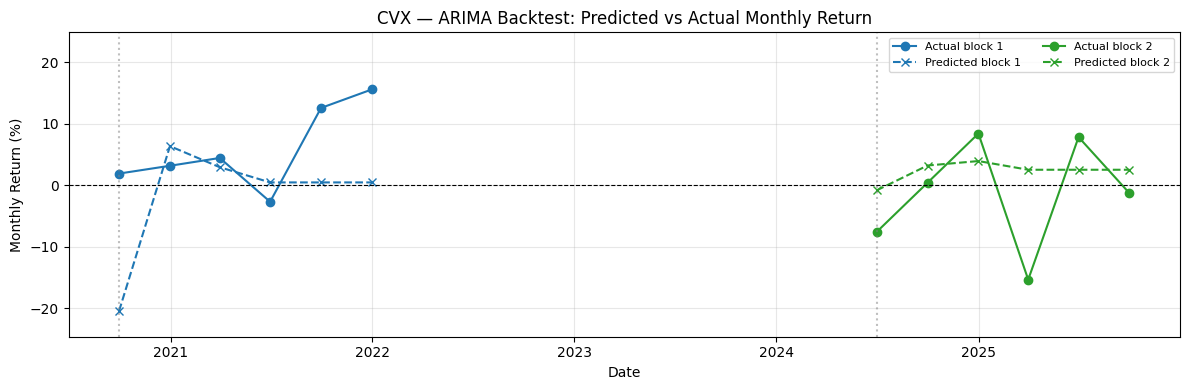

NFG
Best ARIMA order: (2, 0, 4) with Expected Return: 1.4056


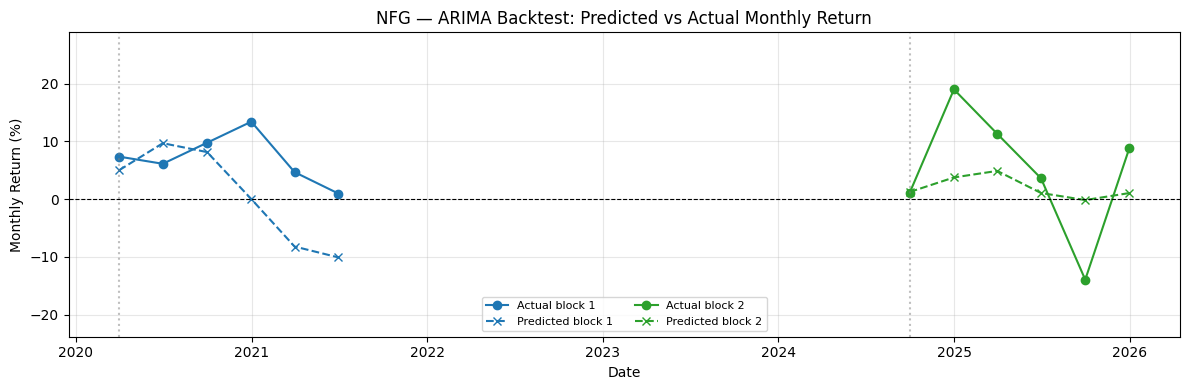

DVN
Best ARIMA order: (3, 0, 0) with Expected Return: 0.8132


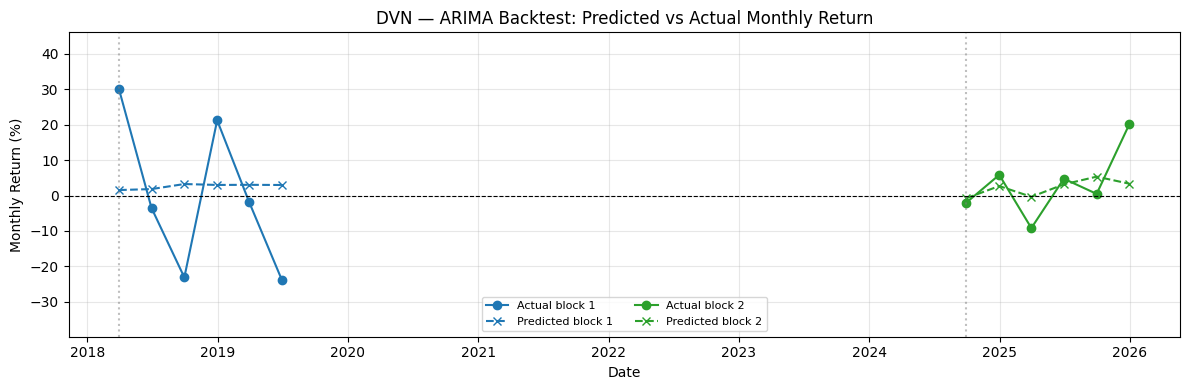

EXE
Best ARIMA order: (1, 0, 3) with Expected Return: 0.3453


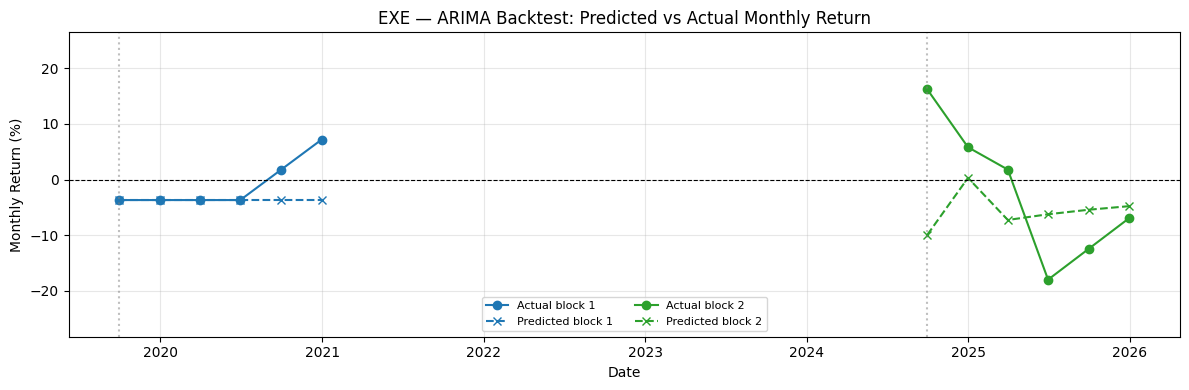

MTDR
Best ARIMA order: (0, 0, 4) with Expected Return: 0.2535


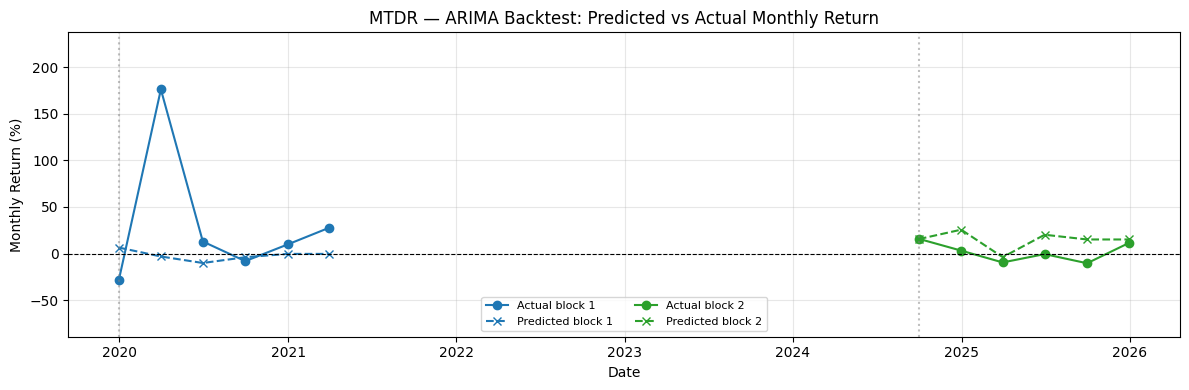

CNX
Best ARIMA order: (0, 0, 3) with Expected Return: 0.5627


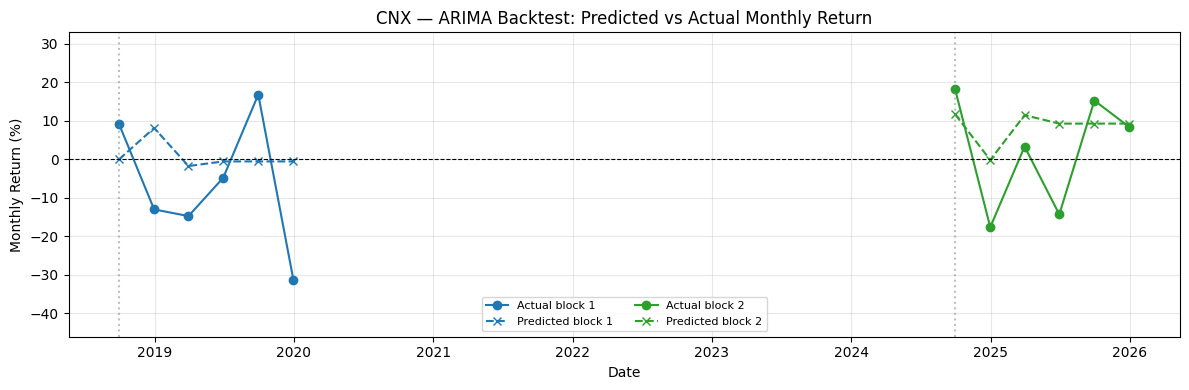

NOG
  Skipping NOG: No valid ARIMA order found — all orders scored <= 0 or failed
RRC
LU decomposition error.
Best ARIMA order: (3, 1, 3) with Expected Return: 0.5673


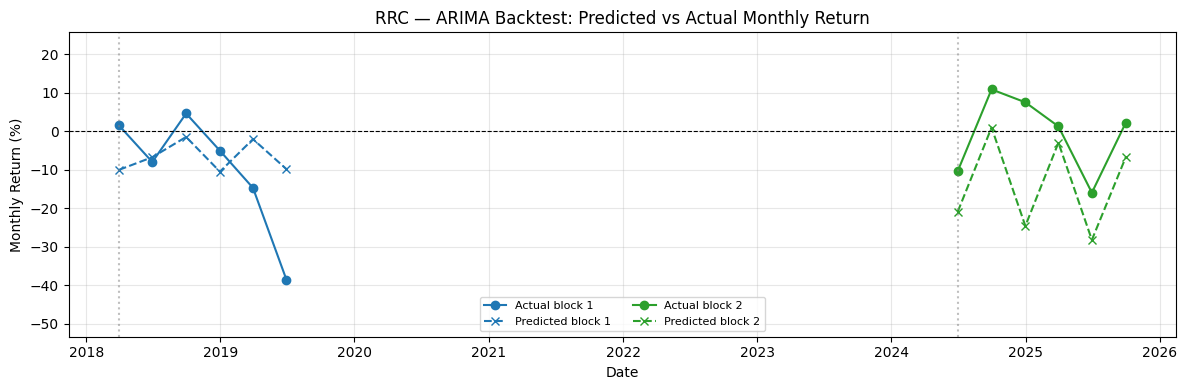

TALO
LU decomposition error.
Best ARIMA order: (2, 1, 1) with Expected Return: 0.3836


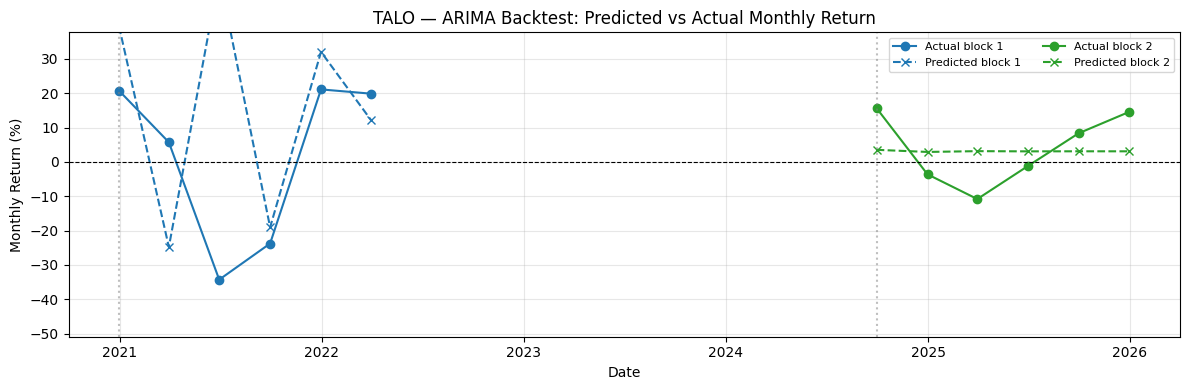

In [81]:
TEST_SIZE = 6
WINDOW_SIZE = 20

y_aligned_stationary.clear()
arima_model_stationary.clear()
backtest_stationary.clear()
y_aligned_unit_root.clear()
arima_model_unit_root.clear()
backtest_unit_root.clear()

for x in ticker_data_dict_stationary.keys():
    print(x)
    try:
        y_aligned_stationary[x], arima_model_stationary[x], backtest_stationary[x] = train_ARIMA(ticker_data_dict_stationary[x], 0, window_size=WINDOW_SIZE, test_size=TEST_SIZE)
        plot_backtest(x, backtest_stationary[x])
    except ValueError as e:
        print(f"  Skipping {x}: {e}")

for x in ticker_data_dict_unit_root.keys():
    print(x)
    try:
        y_aligned_unit_root[x], arima_model_unit_root[x], backtest_unit_root[x] = train_ARIMA(ticker_data_dict_unit_root[x], 1, window_size=WINDOW_SIZE, test_size=TEST_SIZE)
        plot_backtest(x, backtest_unit_root[x])
    except ValueError as e:
        print(f"  Skipping {x}: {e}")

CVX


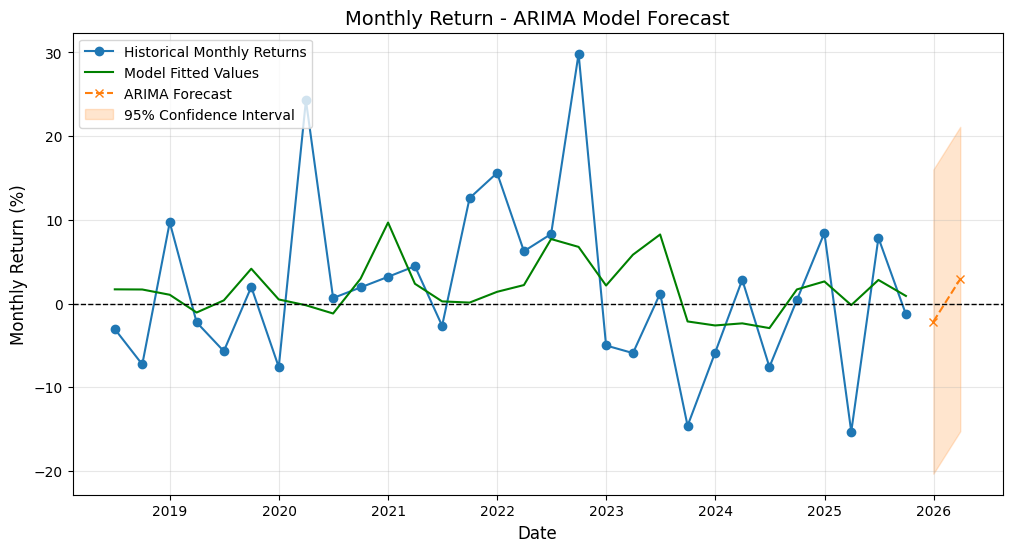

NFG


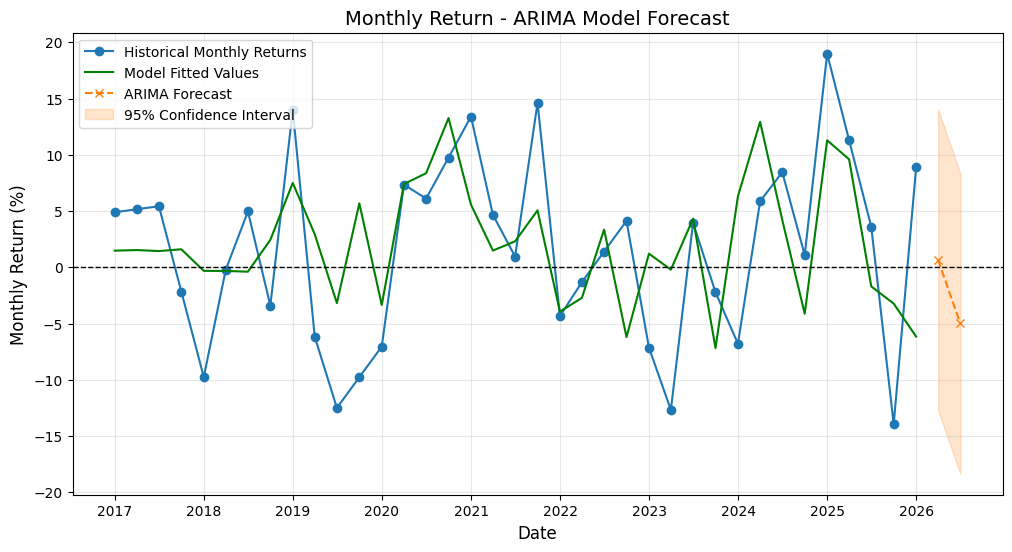

DVN


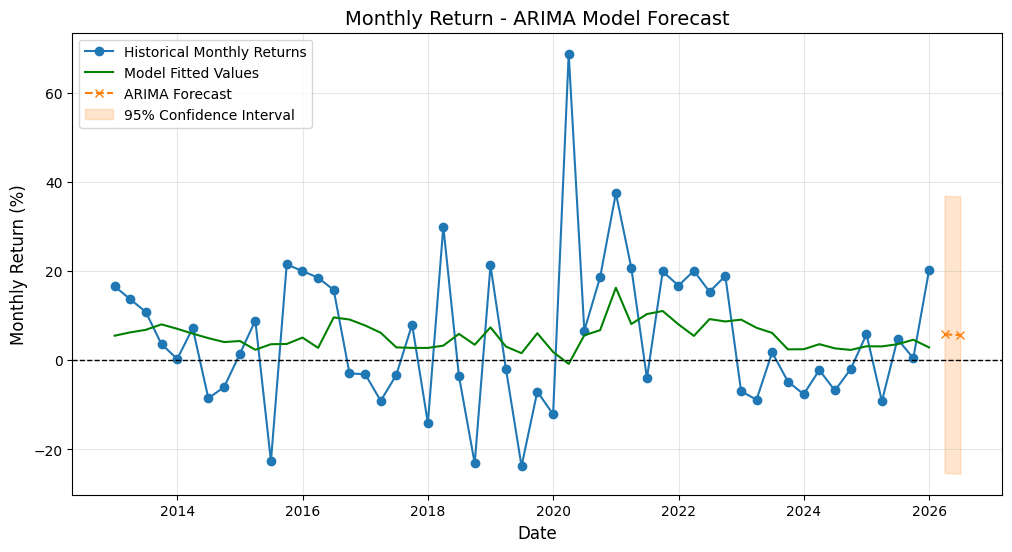

EXE


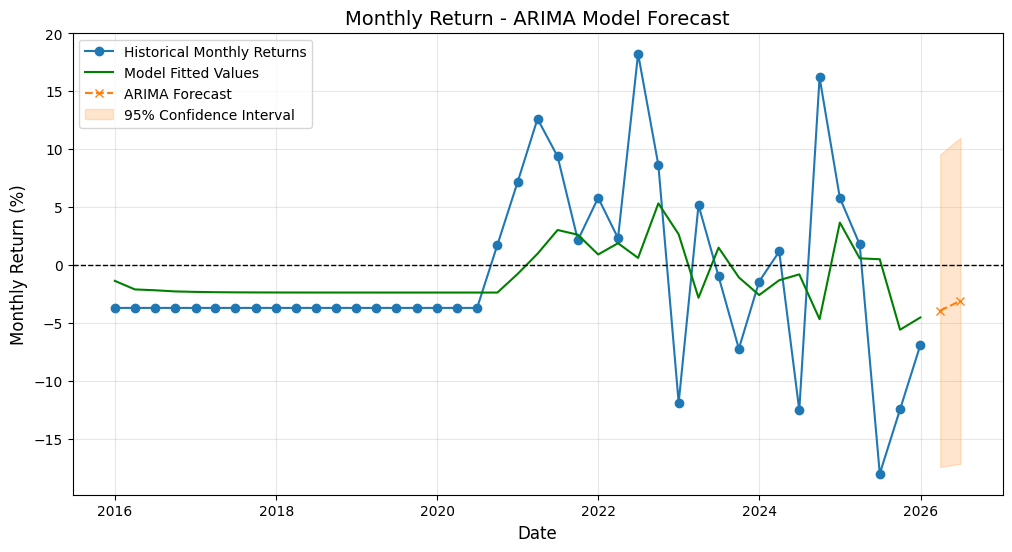

MTDR


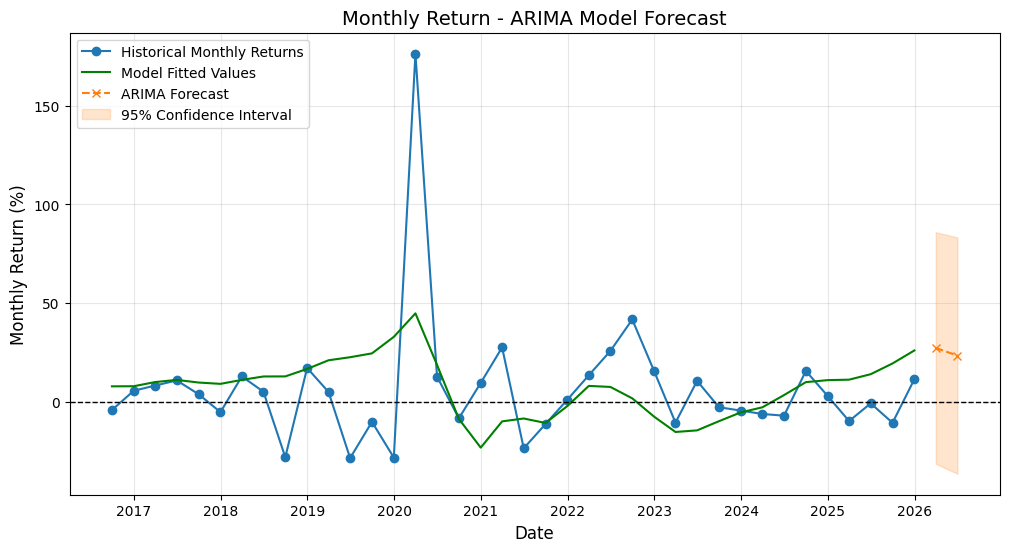

CNX


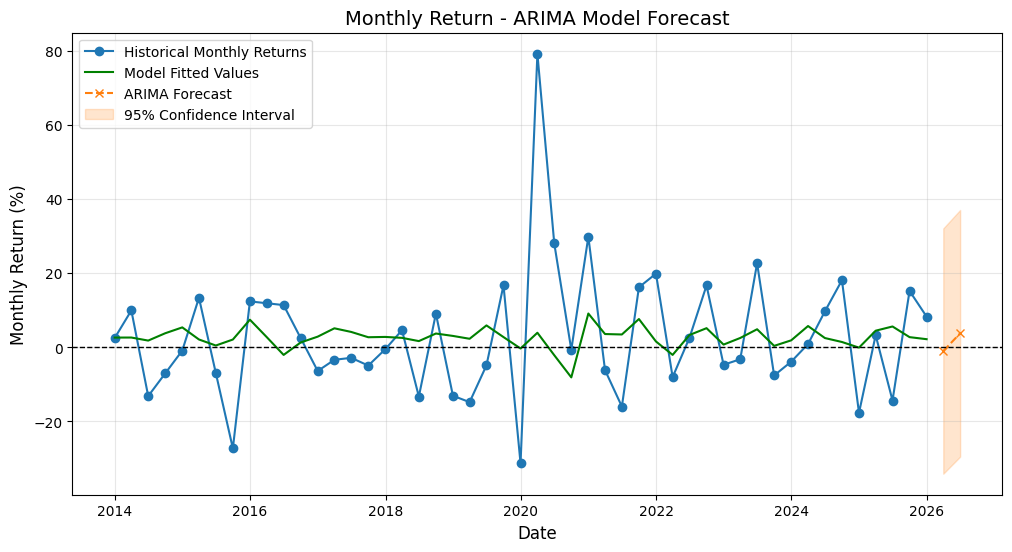

RRC


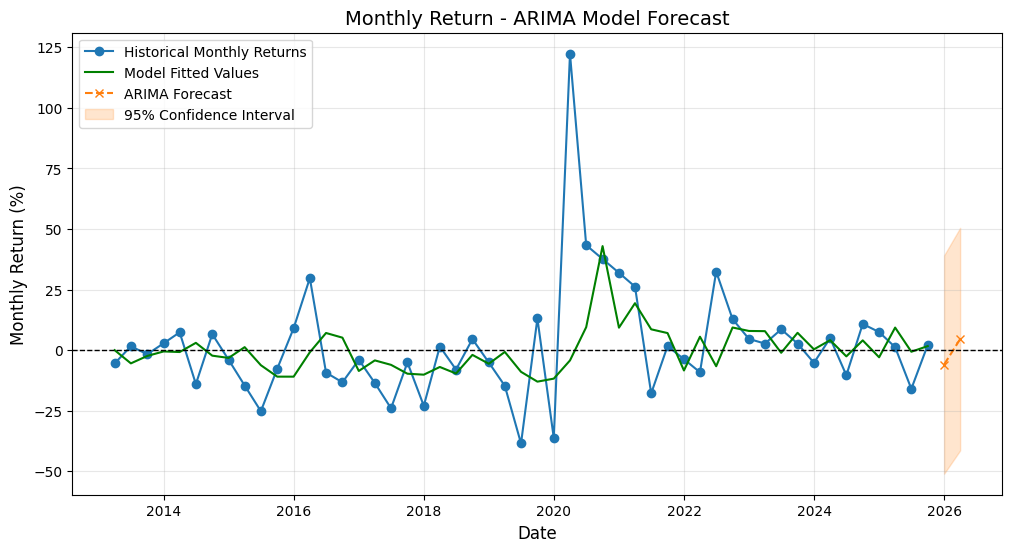

TALO


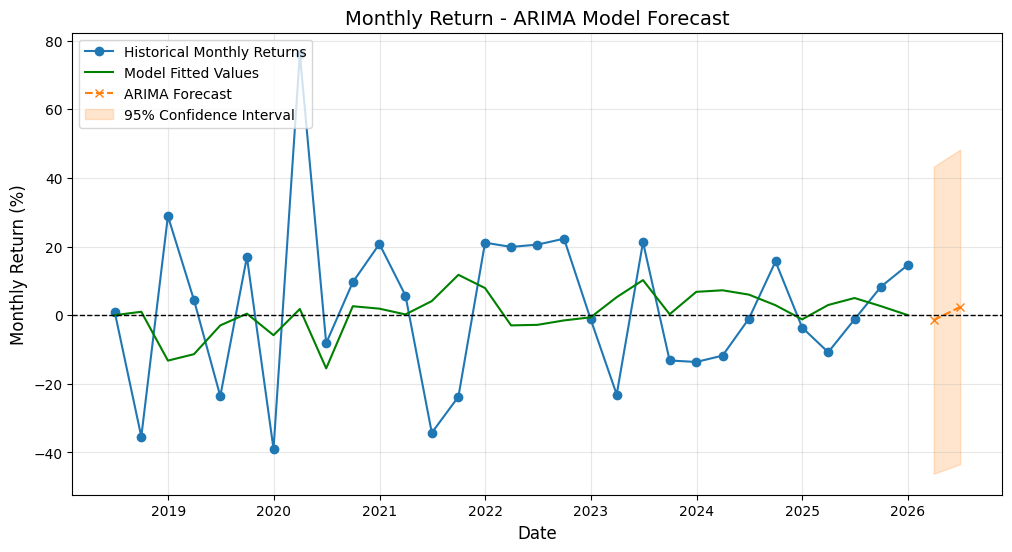

In [82]:
arima_models = {
    **arima_model_stationary,
    **arima_model_unit_root
}

y_aligned_vals = {
    **y_aligned_stationary,
    **y_aligned_unit_root
}

cumulative_returns = {}
all_stocks = [x for x in stationary + unit_root if x in arima_models]

for stock_ticker in all_stocks:
    try:
        print(stock_ticker)
        y_aligned = y_aligned_vals[stock_ticker]
        arima_model = arima_models[stock_ticker]
        cumulative_returns[stock_ticker] = ARIMA_Stock_Analysis(2, y_aligned, arima_model)
    except Exception as e:
        print(e)

Compute Stock Ranking

In [83]:
cumulative_returns

{'CVX': np.float64(0.7123272140889148),
 'NFG': np.float64(-4.353929736157114),
 'DVN': np.float64(11.774150377176461),
 'EXE': np.float64(-6.8888677789130215),
 'MTDR': np.float64(57.505190688110595),
 'CNX': np.float64(2.79020349643615),
 'RRC': np.float64(-1.6571838511345915),
 'TALO': np.float64(0.9298370313598703)}

In [84]:
df_returns = pd.DataFrame(list(cumulative_returns.items()), columns=["Ticker", "Cumulative Return (%)"])
df_sorted = df_returns.sort_values(by="Cumulative Return (%)", ascending=False).reset_index(drop=True)
df_sorted

,Ticker,Cumulative Return (%)
0,MTDR,57.505191
1,DVN,11.774150
2,CNX,2.790203
3,TALO,0.929837
4,CVX,0.712327
5,RRC,-1.657184
6,NFG,-4.353930
7,EXE,-6.888868
